#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
genes_df = pd.read_csv('../../../input/reference_genome/Genebody.mm10.bed', sep='\t', header=None, names=['chromosome', 'start', 'end', 'gene_id', 'gene_name', 'strand'])

In [ ]:
modification="5hmCG"
state="hyper"

DMR_states_df=ad.read_h5ad(f"{indir}/{modification}_DMR_states_neuron_1vsOthers.h5ad").to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index

def get_midpoint_bin(segment_):
    chrom_, start_, end_ = segment_.split("_")
    return int((int(end_)+int(start_)-1)/2/10_000)                        

differential_segments_by_chrom={chrom_ : [(i, get_midpoint_bin(i)) for i in differential_segments if i.split("_")[0]==chrom_] for chrom_ in ["chr"+str(j) for j in range(1,20)]}

In [5]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import cooltools
import cooler

In [6]:
import datetime
from matplotlib.colors import LogNorm

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = f"{indir}/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
# with open("/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/sample_info/04_order_for_class_subclass/subclass_order_for_integration_with_zeng.txt", "rt") as f:
#     subclass_list=f.read().split("\n")[:-1]
# subclass_list=[i for i in subclass_list if "NN" not in i]

subclass_list=['DG Glut', 'Pvalb Gaba'] # just the two subclasses for display
csv_path = "../../../input/01-youth/subclass_our_liu.csv"
df = pd.read_csv(csv_path, sep=',')
df = df[df['subclass_our'].apply(lambda x : x in subclass_list)]
df

,subclass_our,subclass_liu
12,DG Glut,DG_Glut
20,Pvalb Gaba,Pvalb_Gaba


In [ ]:
#chrom_=genes_df[genes_df["gene_id"]==x].loc[:,"chromosome"].iloc[0]
print(f"initialization started at  {datetime.datetime.now()}")
resolution_=10_000

mcool_file={subclass_liu : f'{indir}/{subclass_liu}.Q.10K.mcool'
           for subclass_liu in df['subclass_liu']}
clr={subclass_liu : cooler.Cooler(f'{mcool_file[subclass_liu]}::resolutions/{resolution_}') for subclass_liu in df['subclass_liu']}
matrixes_={
    chrom_ : 
           [
               clr[subclass_liu].matrix(balance=True).fetch(chrom_)[:] 
                     for subclass_liu in df['subclass_liu']
           ] 
           for chrom_ in ["chr"+str(i) for i in [11] ] # only relevant chromosomes are loaded
}
print(f"initialization finished at {datetime.datetime.now()}")

initialization started at  2024-12-29 14:27:25.303715
initialization finished at 2024-12-29 14:27:28.914567


In [ ]:
# manually doing: import cooltools.lib.plotting

from matplotlib import colormaps
import matplotlib as mpl
register_cmap = colormaps.register
PALETTES = {
    "fall": np.array(
        (
            (255, 255, 255),
            (255, 255, 204),
            (255, 237, 160),
            (254, 217, 118),
            (254, 178, 76),
            (253, 141, 60),
            (252, 78, 42),
            (227, 26, 28),
            (189, 0, 38),
            (128, 0, 38),
            (0, 0, 0),
        )
    )
    / 255,
    "blues": np.array(
        (
            (255, 255, 255),
            (180, 204, 225),
            (116, 169, 207),
            (54, 144, 192),
            (5, 112, 176),
            (4, 87, 135),
            (3, 65, 100),
            (2, 40, 66),
            (1, 20, 30),
            (0, 0, 0),
        )
    )
    / 255,
    "acidblues": np.array(
        (
            (255, 255, 255),
            (162, 192, 222),
            (140, 137, 187),
            (140, 87, 167),
            (140, 45, 143),
            (120, 20, 120),
            (90, 15, 90),
            (60, 10, 60),
            (30, 5, 30),
            (0, 0, 0),
        )
    )
    / 255,
    "nmeth": np.array(
        (
            (236, 250, 255),
            (148, 189, 217),
            (118, 169, 68),
            (131, 111, 43),
            (122, 47, 25),
            (41, 0, 20),
        )
    )
    / 255,
}


def list_to_colormap(color_list, name=None):
    color_list = np.array(color_list)
    if color_list.min() < 0:
        raise ValueError("Colors should be 0 to 1, or 0 to 255")
    if color_list.max() > 1.0:
        if color_list.max() > 255:
            raise ValueError("Colors should be 0 to 1 or 0 to 255")
        else:
            color_list = color_list / 255.0
    return mpl.colors.LinearSegmentedColormap.from_list(name, color_list, 256)


def get_cmap(name):
    is_reversed = name.endswith("_r")
    try:
        if is_reversed:
            pal = PALETTES[name[:-2]][::-1]
        else:
            pal = PALETTES[name]
    except KeyError:
        raise ValueError('Palette not found "{}"'.format(name))
    return list_to_colormap(pal)


def _register_cmaps():
    for name, pal in PALETTES.items():
        register_cmap(cmap=list_to_colormap(pal), name=name)
        register_cmap(cmap=list_to_colormap(pal[::-1]), name=name + "_r")


_register_cmaps()


def gridspec_inches(wcols, hrows, fig_kwargs={}):

    fig_height_inches = sum(hrows)

    fig_width_inches = sum(wcols)

    fig = plt.figure(
        figsize=(fig_width_inches, fig_height_inches),
        subplotpars=mpl.figure.SubplotParams(
            left=0, right=1, bottom=0, top=1, wspace=0, hspace=0.0
        ),
        # frameon=False,
        **fig_kwargs
    )
    fig.set_size_inches(fig_width_inches, fig_height_inches, forward=True)

    gs = mpl.gridspec.GridSpec(
        len(hrows),
        len(wcols),
        left=0,
        right=1,
        top=1,
        bottom=0,
        wspace=0,
        hspace=0,
        width_ratios=wcols,
        height_ratios=hrows,
    )

    return fig, gs

In [ ]:
    # axs[i][j].set_title(low_mid_hight_subclass[i*3+j]+" --- RNA "+['lowest', 'low', 'low', 'mid', 'mid', 'mid', 'high', 'high', 'highest'][i])
    # axs[i][j].set_xticks(segment_bins + [gene_start_/10_000, gene_end_/10_000])
    # axs[i][j].set_xticklabels(['I'] * len(segment_bins) + ['TSS', 'TES'])
    # tick_labels = axs[i][j].get_xticklabels()  # Get current xtick labels
    # colors = ['skyblue'] * len(segment_bins) + ['limegreen', 'limegreen']  # List of colors for each tick
    # for label, color in zip(tick_labels, colors):
    #     label.set_color(color)
    # axs[i][j].
    # axs[i][j].hlines([TSS_bin, TES_bin], plot_upper_bin , plot_upper_bin-border, color='limegreen', linewidth=0.7)
    # axs[i][j].vlines(segment_bins, plot_lower_bin , plot_lower_bin+border, color='skyblue', linewidth=0.7)
    # axs[i][j].vlines(segment_bins, plot_upper_bin , plot_upper_bin-border, color='skyblue', linewidth=0.7)

In [156]:
genes_df[genes_df['gene_name']=='Zpbp']

,chromosome,start,end,gene_id,gene_name,strand
32304,chr11,11279626,11462408,ENSMUSG00000020193.3,Zpbp,-


In [153]:
gene_

,chromosome,start,end,gene_id,gene_name,strand
32302,chr11,11114223,11268931,ENSMUSG00000050830.17,Vwc2,+


<Figure size 118.11x118.11 with 0 Axes>

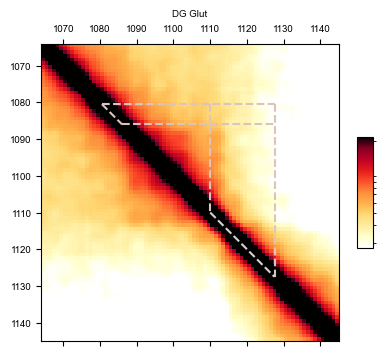

<Figure size 118.11x118.11 with 0 Axes>

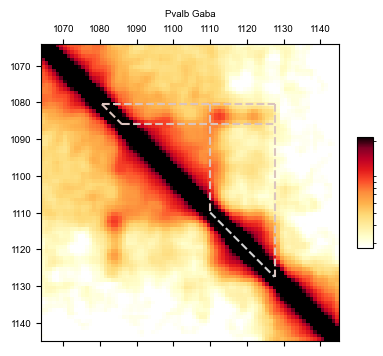

<Figure size 118.11x118.11 with 0 Axes>

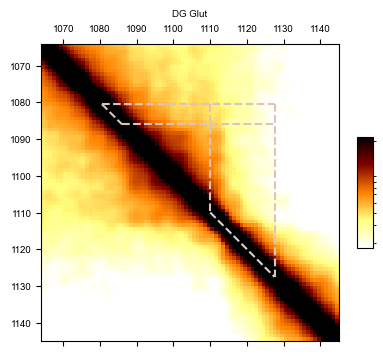

<Figure size 118.11x118.11 with 0 Axes>

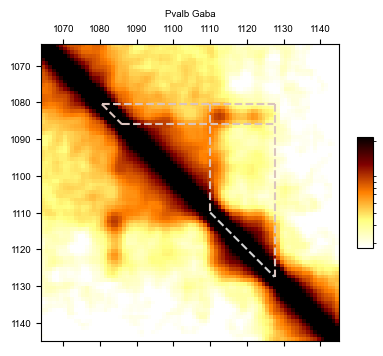

<Figure size 118.11x118.11 with 0 Axes>

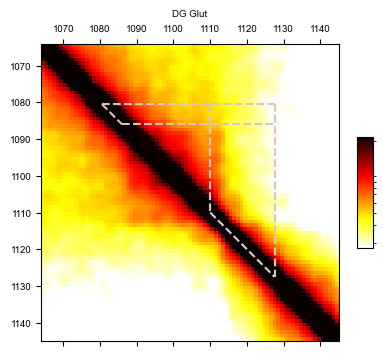

<Figure size 118.11x118.11 with 0 Axes>

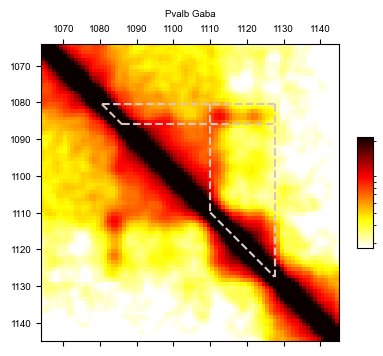

<Figure size 118.11x118.11 with 0 Axes>

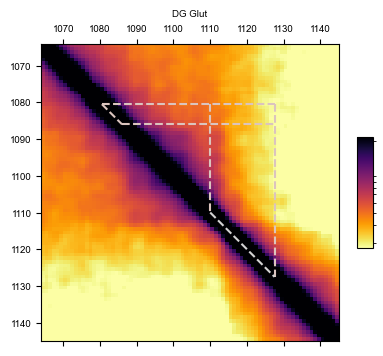

<Figure size 118.11x118.11 with 0 Axes>

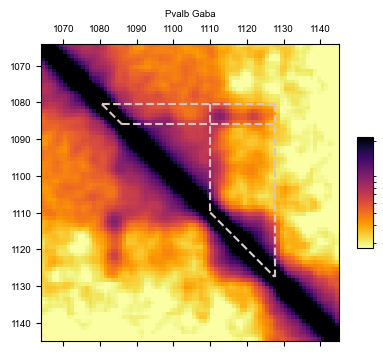

<Figure size 118.11x118.11 with 0 Axes>

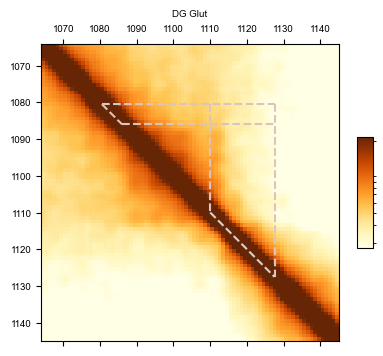

<Figure size 118.11x118.11 with 0 Axes>

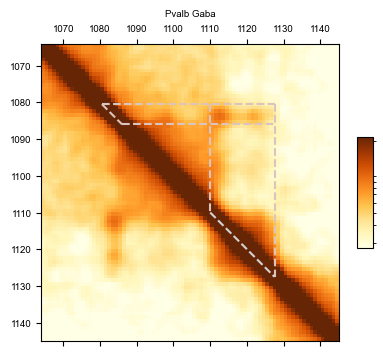

<Figure size 118.11x118.11 with 0 Axes>

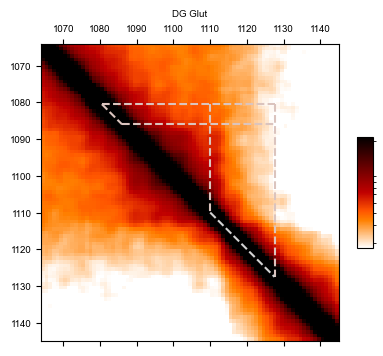

<Figure size 118.11x118.11 with 0 Axes>

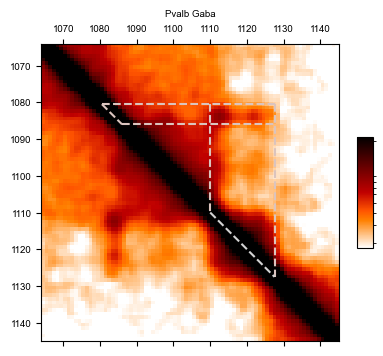

<Figure size 118.11x118.11 with 0 Axes>

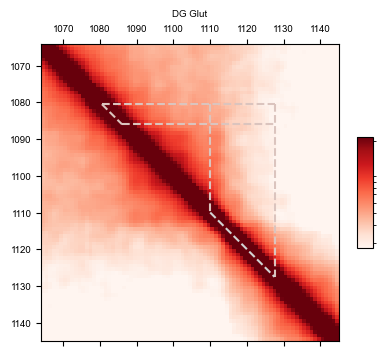

<Figure size 118.11x118.11 with 0 Axes>

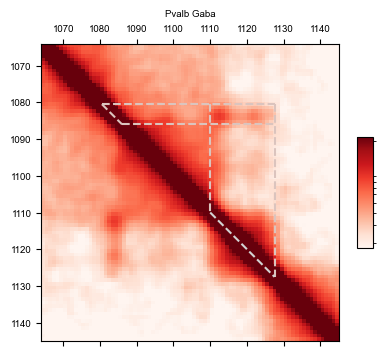

<Figure size 118.11x118.11 with 0 Axes>

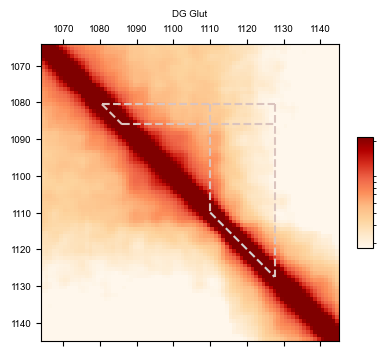

<Figure size 118.11x118.11 with 0 Axes>

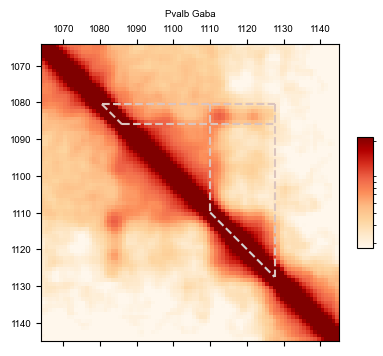

In [ ]:
gene_name_ = 'Vwc2'
gene_ = genes_df[genes_df["gene_name"]==gene_name_]
chrom_, gene_start_, gene_end_, strand_ = gene_.loc[:,["chromosome","start","end","strand"]].iloc[0,:]
gene_start_, gene_end_ = map(int, (gene_start_, gene_end_))
(TSS_, TES_) =(gene_start_, gene_end_)[::(2*(strand_=='+')-1)]
plot_lower_bin=1079-15
plot_upper_bin=1130+15
# plt.matshow works like range(start_, end_). The upper bin itself will not be shown, its start is the right border.
distal_lower, distal_upper, gene_lower, gene_upper = 1080.5, 1086, 1110, 1127.5

for cmap_ in ['fall', 'afmhot_r', 'hot_r', 'inferno_r', 'YlOrBr', 'gist_heat_r', 'Reds', 'OrRd']:
    for subclass_ in subclass_list:
        plt.figure(figsize=(30/25.4, 30/25.4))
        plt.matshow(matrixes_[chrom_][subclass_list.index(subclass_)]\
                       [plot_lower_bin : plot_upper_bin, plot_lower_bin : plot_upper_bin],
                       extent=[plot_lower_bin , plot_upper_bin , plot_upper_bin, plot_lower_bin],
                       norm=LogNorm(vmax=0.022, vmin=0.0018), cmap=cmap_)
        cb = plt.colorbar(shrink=0.3, aspect=7,ticks=[])
        color_for_guide_line='#DBC4BE'
        plt.hlines([distal_lower], distal_lower , gene_upper, color=color_for_guide_line, linestyles='dashed')
        plt.hlines([distal_upper], distal_upper , gene_upper, color=color_for_guide_line, linestyles='dashed')
        plt.vlines([gene_lower], distal_lower , gene_lower, color=color_for_guide_line, linestyles='dashed')
        plt.vlines([gene_upper], distal_lower , gene_upper, color=color_for_guide_line, linestyles='dashed')
        plt.plot((distal_lower, distal_upper), (distal_lower, distal_upper), color=color_for_guide_line, linestyle='dashed')
        plt.plot((gene_lower, gene_upper), (gene_lower, gene_upper), color='lightgrey', linestyle='dashed')
        plt.title(f'{subclass_}', fontdict={'size':7});
        plt.xticks(fontsize=7); plt.yticks(fontsize=7)
        plt.savefig(f'{outdir}/plot_Vwc2-{cmap_}-{subclass_}.pdf')
        plt.savefig(f'{outdir}/plot_Vwc2-{cmap_}-{subclass_}.png', dpi=600)
        plt.show()

In [ ]:
border=30
low_mid_hight_subclass=df_RNA_selected[[gene_id_]].sort_values(by=f'{gene_id_}').index
plot_lower_bin=min(segment_bins+[TSS_bin, TES_bin])-border
plot_upper_bin=max(segment_bins+[TSS_bin, TES_bin])+border
fig, axs = plt.subplots(9,3, sharey=True,figsize=(15,5*9))
for i in range(9):
    for j in range(3):
        if i*3+j ==25:
            break
        axs[i][j].matshow(matrixes_[chrom_][subclass_list.index(low_mid_hight_subclass[i*3+j])]\
                       [plot_lower_bin : plot_upper_bin, plot_lower_bin : plot_upper_bin],
                       extent=[plot_lower_bin , plot_upper_bin , plot_upper_bin, plot_lower_bin],
                       norm=LogNorm(vmax=0.15), cmap="hot_r")
        axs[i][j].set_title(low_mid_hight_subclass[i*3+j]+" --- RNA "+['lowest', 'low', 'low', 'mid', 'mid', 'mid', 'high', 'high', 'highest'][i])
        axs[i][j].set_xticks(segment_bins + [gene_start_/10_000, gene_end_/10_000])
        axs[i][j].set_xticklabels(['I'] * len(segment_bins) + ['TSS', 'TES'])
        tick_labels = axs[i][j].get_xticklabels()  # Get current xtick labels
        colors = ['skyblue'] * len(segment_bins) + ['limegreen', 'limegreen']  # List of colors for each tick
        for label, color in zip(tick_labels, colors):
            label.set_color(color)
        axs[i][j].hlines([TSS_bin, TES_bin], plot_lower_bin , plot_lower_bin+border, color='limegreen', linewidth=0.7)
        axs[i][j].hlines([TSS_bin, TES_bin], plot_upper_bin , plot_upper_bin-border, color='limegreen', linewidth=0.7)
        axs[i][j].vlines(segment_bins, plot_lower_bin , plot_lower_bin+border, color='skyblue', linewidth=0.7)
        axs[i][j].vlines(segment_bins, plot_upper_bin , plot_upper_bin-border, color='skyblue', linewidth=0.7)
plt.show()
